# Camera Calibration

# Open3D Visualize in Google Colab



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install Open3D

In [2]:
!pip install open3d

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.7/399.7 MB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 72.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 62.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.3 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.6
    Uninstalling widgetsnbextension-3.6.6:
      Successfully uninstalled widgetsnbextension-3.6.6
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [3]:
import numpy as np
import open3d as o3d
import plotly.graph_objects as go
from google.colab import drive
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# my_path = '/content/drive/MyDrive/\'Colab Notebooks\'/3DDP/Calibration/'
my_path = '/content/drive/MyDrive/3ddp_calibration/'
%cd $my_path

/content/drive/MyDrive/3ddp_calibration


# Camera Calibration Using OpenCV

## 1. Capture Checkerboards
* 촬영 방법: 본인의 카메라로 다양한 각도, 거리에서 체커보드를 촬영합니다.
* Sample images: img-001.png, ...
* 주의: 샘플 사진을 통해 얻어진 intirnic parameters는 해당 카메라의 값입니다.


## 2. Need Checkerboard Information
* nH: x 방향 cross-corner 개수
* nV: y 방향 cross-corner 개수
* nSize: 정사각형의 한 변의 길이 (mm)

Reference: https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html


In [15]:
import glob

# 패턴 정보
nH = 9
nV = 6
# 실제 크기에 맞게 쓰세요
nSize = 26.111

#  image names
images = glob.glob('./checkboard/*.jpg')

print((cv2.imread(images[0])).shape)

CHECKERBOARD = (nV,nH)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
# 각 체커보드 이미지에 대한 3D 점 벡터를 저장할 벡터 생성
objpoints = []
# 각 체커보드 이미지에 대한 2D 점 벡터를 저장할 벡터 생성
imgpoints = []
# 3D 점의 세계 좌표 정의
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2) * nSize
prev_img_shape = None

for fname in images:
    img = cv2.imread(fname)
    img = cv2.resize(img,dsize = (img.shape[0]//4,img.shape[0]//4),interpolation=cv2.INTER_LINEAR)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray,
                                             CHECKERBOARD,
                                             cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

    if ret == True:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
        imgpoints.append(corners2)
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
    cv2_imshow(cv2.resize(img,  dsize=(0, 0), fx=0.4, fy=0.4, interpolation=cv2.INTER_LINEAR))

h,w = img.shape[:2]
# 알려진 3D 점(objpoints) 값과 감지된 코너의 해당 픽셀 좌표(imgpoints) 전달, 카메라 캘리브레이션 수행
ret, intrinsic, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)




Output hidden; open in https://colab.research.google.com to view.

## Check your camera intrinsic parameters
* Intrinsic matrix (3x3)
* Distortion coefficient (1x5)


In [16]:
print("Intrinsic matrix : \n")
print(intrinsic)

print("dist : \n") # 렌즈 왜곡 계수(Lens distortion coefficients)
print(dist)

print(type(intrinsic))
print(type(dist))
print(intrinsic.dtype)
print(dist.dtype)



Intrinsic matrix : 

[[1.06979350e+03 0.00000000e+00 5.46920816e+02]
 [0.00000000e+00 8.14587049e+02 5.24539215e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist : 

[[ 6.36415927e-01 -4.40639303e+00  6.06451493e-03  3.43165310e-03
   4.91935743e+00]]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
float64
float64


# Convert 2D Image to 3D

## 1. Capture Scene
* Intrinsic parameter를 찾은 카메라로 배경 사진을 촬영합니다.
* 아래 과정은 모든 픽셀이 1m 앞의 물체를 촬영했다고 가정합니다.

In [ ]:
img_real = cv2.imread('./khu.jpg')
cv2_imshow(img_real)

h, w, ch = img_real.shape
colors = []
points = []

f_x = intrinsic[0,0]
f_y = intrinsic[1,1]
c_x = intrinsic[0,2]
c_y = intrinsic[1,2]

sampling_rate = 10

for v in range(0,h,sampling_rate):
  for u in range(0,w,sampling_rate):
    color = img_real[int(v),int(u),:]
    Z = 0.5 #임의의 3D 공간에 Z 값을 0.5m 로 고정
    X = (u - c_x) * Z / f_x
    Y = (v - c_y) * Z / f_y
    points.append([X,Y,Z])
    colors.append([color[2]/255.0,color[1]/255.0,color[0]/255.0])

points=np.array(points)
colors=np.array(colors)

# Convert to Open3D.PointCLoud:
pcd_o3d = o3d.geometry.PointCloud()  # create a point cloud object
pcd_o3d.points = o3d.utility.Vector3dVector(points)
pcd_o3d.colors=o3d.utility.Vector3dVector(colors)



Output hidden; open in https://colab.research.google.com to view.

## 2. Visualization using Open3D
* Open3D 를 사용하여 pointcloud를 시각화 합니다.
* o3d.visualization.draw_geometries() 함수는 Google Colab 에서 동작하지 않습니다. 아래 시각화는 Colab에서 동작할 수 있게 수정한 것입니다.

# Convert 2D Image into 3D Point Cloud

In [ ]:
def draw_geometries(geometries):
    graph_objects = []

    for geometry in geometries:
        geometry_type = geometry.get_geometry_type()

        if geometry_type == o3d.geometry.Geometry.Type.PointCloud:
            points = np.asarray(geometry.points)
            colors = None
            if geometry.has_colors():
                colors = np.asarray(geometry.colors)
            elif geometry.has_normals():
                colors = (0.5, 0.5, 0.5) + np.asarray(geometry.normals) * 0.5
            else:
                geometry.paint_uniform_color((0.0, 0.0, 0.0))
                colors = np.asarray(geometry.colors)

            scatter_3d = go.Scatter3d(x=points[:,0], y=points[:,1], z=points[:,2], mode='markers', marker=dict(size=1, color=colors))
            graph_objects.append(scatter_3d)

        if geometry_type == o3d.geometry.Geometry.Type.TriangleMesh:
            triangles = np.asarray(geometry.triangles)
            vertices = np.asarray(geometry.vertices)
            colors = None
            if geometry.has_triangle_normals():
                colors = (0.5, 0.5, 0.5) + np.asarray(geometry.triangle_normals) * 0.5
                colors = tuple(map(tuple, colors))
            else:
                colors = (1.0, 0.0, 0.0)

            mesh_3d = go.Mesh3d(x=vertices[:,0], y=vertices[:,1], z=vertices[:,2], i=triangles[:,0], j=triangles[:,1], k=triangles[:,2], facecolor=colors, opacity=0.50)
            graph_objects.append(mesh_3d)

    fig = go.Figure(
        data=graph_objects,
        layout=dict(
            scene=dict(
                xaxis=dict(visible=False),
                yaxis=dict(visible=False),
                zaxis=dict(visible=False)
            )
        )
    )
    fig.show()
o3d.visualization.draw_geometries = draw_geometries # replace function

In [ ]:
o3d.visualization.draw_geometries([pcd_o3d])

Output hidden; open in https://colab.research.google.com to view.

## 3. Depth Image Back Projection

(540, 960)
Depth Image


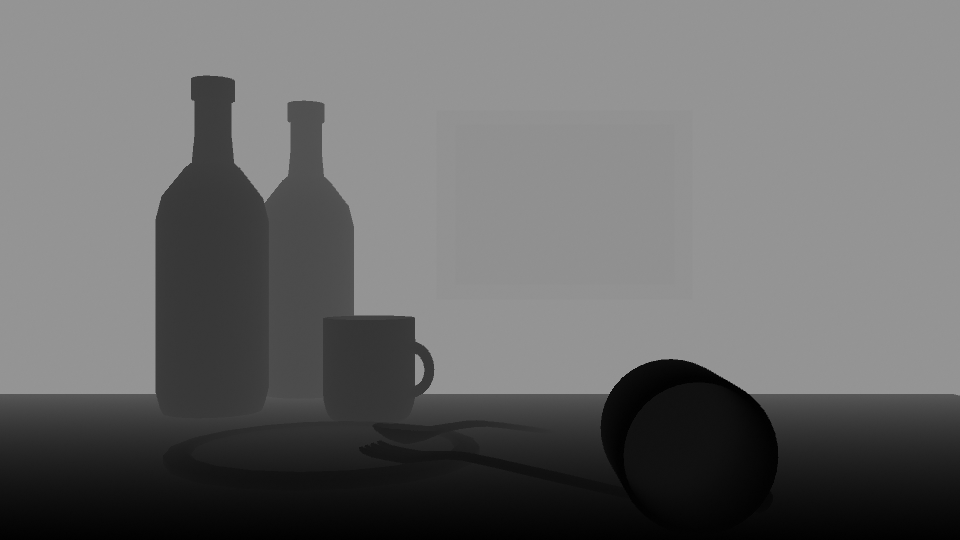

(196954, 3)


In [ ]:
## undistort 된 depth 이미지를 읽어옵니다.
depth_image = cv2.imread('./depth.png', 2)
print(depth_image.shape)

print('Depth Image')
cv2_imshow(depth_image)
depth_image = depth_image / 255.0

f_x = intrinsic[0,0]
f_y = intrinsic[1,1]
c_x = intrinsic[0,2]
c_y = intrinsic[1,2]

h,w = depth_image.shape
sampling_rate = 1

points = []
for v in range(0,h,sampling_rate):
  for u in range(0,w,sampling_rate):
    if depth_image[v,u] > 0.4 or depth_image[v,u] <= 0.0: # background remover
      continue
    Z = depth_image[v,u]
    X = (u - c_x) * Z / f_x
    Y = (v - c_y) * Z / f_y
    points.append([X,Y,Z])

np_points = np.array(points) # list -> numpy
pcd_o3d = o3d.geometry.PointCloud() # numpy -> open3d
pcd_o3d.points = o3d.utility.Vector3dVector(np_points)
print(np_points.shape)

In [ ]:
o3d.visualization.draw_geometries([pcd_o3d])

Output hidden; open in https://colab.research.google.com to view.